# 03. Train LSTM

전처리 결과를 사용해 `LSTM`을 학습하고 성능을 저장합니다.

In [1]:

%matplotlib inline

import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

try:
    import tensorflow as tf
except ImportError as error:
    raise ImportError('tensorflow가 설치되어 있지 않습니다.') from error

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str((OUTPUT_DIR / '.mplconfig').resolve()))
(OUTPUT_DIR / '.mplconfig').mkdir(parents=True, exist_ok=True)

RUN_SEEDS = [42]
LSTM_EPOCHS = 20
BATCH_SIZE = 256
LEARNING_RATE = 0.001


In [2]:
def print_section(title: str) -> None:
    # 구간 출력
    line = '=' * 50
    print('\n' + line)
    print(title)
    print(line)


def set_seed(seed: int) -> None:
    # 시드 고정
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    # 성능 계산
    y_pred = (np.asarray(y_prob) >= threshold).astype(np.int32)
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1_score': float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
    }


def load_data() -> dict:
    # 시퀀스 로드
    print_section('[INFO] LSTM 데이터 로드')
    required = ['X_train_seq.npy', 'X_val_seq.npy', 'X_test_seq.npy', 'y_train.npy', 'y_val.npy', 'y_test.npy', 'test_sample_ids.npy']
    missing = [name for name in required if not (OUTPUT_DIR / name).exists()]
    if missing:
        raise FileNotFoundError(f'먼저 01_prepare_data.ipynb를 실행하세요: {missing}')
    return {
        'X_train_seq': np.load(OUTPUT_DIR / 'X_train_seq.npy').astype(np.float32),
        'X_val_seq': np.load(OUTPUT_DIR / 'X_val_seq.npy').astype(np.float32),
        'X_test_seq': np.load(OUTPUT_DIR / 'X_test_seq.npy').astype(np.float32),
        'y_train_seq': np.load(OUTPUT_DIR / 'y_train.npy').astype(np.int32),
        'y_val_seq': np.load(OUTPUT_DIR / 'y_val.npy').astype(np.int32),
        'y_test_seq': np.load(OUTPUT_DIR / 'y_test.npy').astype(np.int32),
        'test_sample_ids': np.load(OUTPUT_DIR / 'test_sample_ids.npy').astype(np.int32),
    }


def build_model(input_shape: tuple[int, int]):
    # 모델 정의
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model


def save_json(path: Path, payload: dict) -> None:
    # json 저장
    with open(path, 'w', encoding='utf-8') as file:
        json.dump(payload, file, ensure_ascii=False, indent=2)


def save_predictions(path: Path, sample_ids: np.ndarray, y_true: np.ndarray, y_prob: np.ndarray) -> None:
    # 예측 저장
    pd.DataFrame({'sample_id': sample_ids, 'y_true': y_true, 'y_prob': y_prob}).to_csv(path, index=False)


def find_best_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    # 임계값 탐색
    candidates = np.linspace(0.1, 0.9, 81)
    best_threshold = 0.5
    best_tuple = (-1.0, -1.0, -1.0)
    for threshold in candidates:
        metrics = compute_metrics(y_true, y_prob, threshold=threshold)
        current = (metrics['f1_score'], metrics['recall'], metrics['precision'])
        if current > best_tuple:
            best_tuple = current
            best_threshold = float(threshold)
    return best_threshold


def make_class_weight(y_train: np.ndarray) -> dict:
    # 가중치 생성
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    return {int(label): float(weight) for label, weight in zip(classes, weights)}



[INFO] LSTM 데이터 로드

[INFO] LSTM 학습 시작


E0000 00:00:1775448745.075200 3159077 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


E0000 00:00:1775448754.489766 3159077 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1775448788.344266 3159077 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


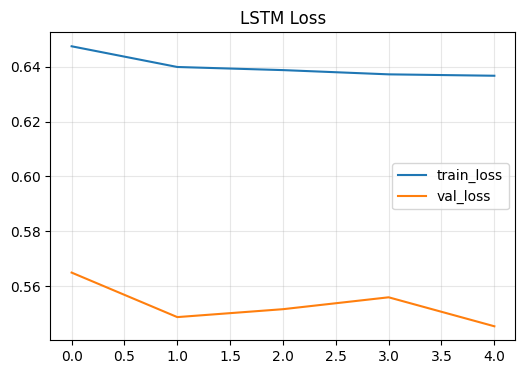

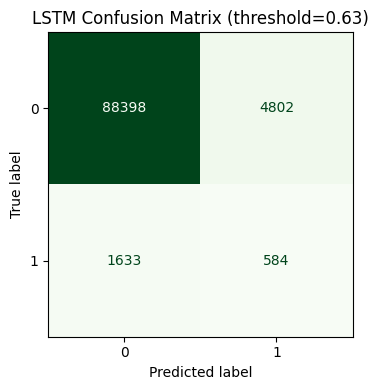

,accuracy,precision,recall,f1_score,roc_auc,confusion_matrix,threshold
0,0.9326,0.1084,0.2634,0.1536,0.7419,"[[88398, 4802], [1633, 584]]",0.63


In [3]:
# 실행
data = load_data()

print_section('[INFO] LSTM 학습 시작')
class_weight = make_class_weight(data['y_train_seq'])
best_run = None
best_val_auc = -np.inf
run_rows = []

for seed in RUN_SEEDS:
    set_seed(seed)
    model = build_model((data['X_train_seq'].shape[1], data['X_train_seq'].shape[2]))
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=4,
            restore_best_weights=True,
            verbose=0,
        )
    ]
    history = model.fit(
        data['X_train_seq'],
        data['y_train_seq'],
        validation_data=(data['X_val_seq'], data['y_val_seq']),
        epochs=LSTM_EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=callbacks,
        class_weight=class_weight,
    )
    val_prob = model.predict(data['X_val_seq'], verbose=0).ravel()
    test_prob = model.predict(data['X_test_seq'], verbose=0).ravel()
    threshold = find_best_threshold(data['y_val_seq'], val_prob)
    val_auc = roc_auc_score(data['y_val_seq'], val_prob)
    metrics = compute_metrics(data['y_test_seq'], test_prob, threshold=threshold)
    run_rows.append({'seed': seed, 'threshold': threshold, **metrics})
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_run = {
            'seed': seed,
            'threshold': threshold,
            'model': model,
            'history': history.history,
            'metrics': metrics,
            'y_prob': test_prob,
        }

save_predictions(OUTPUT_DIR / 'lstm_test_predictions.csv', data['test_sample_ids'], data['y_test_seq'], best_run['y_prob'])
save_json(OUTPUT_DIR / 'lstm_metrics.json', {
    'model_name': 'LSTM',
    'run_count': len(run_rows),
    'aggregate': {f'{metric}_mean': float(np.mean([row[metric] for row in run_rows])) for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']},
    'best_run': {key: value.tolist() if hasattr(value, 'tolist') else value for key, value in best_run['metrics'].items()} | {'seed': best_run['seed'], 'threshold': best_run['threshold']},
    'prediction_path': 'lstm_test_predictions.csv',
    'threshold': best_run['threshold'],
    'history': {key: [float(value) for value in values] for key, values in best_run['history'].items()},
    'interpretation_note': '최근 주문 흐름을 직접 반영한 모델입니다.',
})
best_run['model'].save(OUTPUT_DIR / 'lstm_model.keras')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(best_run['history']['loss'], label='train_loss')
ax.plot(best_run['history']['val_loss'], label='val_loss')
ax.set_title('LSTM Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(best_run['metrics']['confusion_matrix']).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f"LSTM Confusion Matrix (threshold={best_run['threshold']:.2f})")
plt.tight_layout()
plt.show()

pd.DataFrame([best_run['metrics'] | {'threshold': best_run['threshold']}]).round(4)
